In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn
!pip install transformers datasets sentence-transformers faiss-cpu
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 135.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset
import torch

In [4]:
file_path = "zends_raw50k_20c.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (50000, 20)


,query,intent,sentiment,country,product_group,plan,plan_type,customer_type,priority,status,request_date,amount_billed,data_usage_gb,call_minutes,support_ticket_id,overcharged_flag,refund_eligible,late_payment_flag,support_response_time_hrs,satisfaction_score
0,How do I get a new connection for ZENDOffice N...,New Connection,Neutral,USA,Home & Office Internet,ZENDOffice Net 200,Office Broadband,Individual,Enterprise,Closed,2026-01-30,39.99,1971.55,0,TICKET00001,No,No,No,4,3
1,Complaint regarding ZENDBiz Connect 1G.,Complaint,Angry,India,Business Connectivity,ZENDBiz Connect 1G,Business Plan,Enterprise,Enterprise,Resolved,2026-01-19,484.01,812.47,0,TICKET00002,No,No,No,40,1
2,Need replacement for Prepaid Basic 5GB device.,Device / SIM Issue,Satisfied,Thailand,Mobile Connectivity,Prepaid Basic 5GB,Prepaid,Individual,Enterprise,In Progress,2026-01-12,136.77,655.94,936,TICKET00003,No,No,No,60,4
3,Need replacement for ZENDOffice Net 500 device.,Device / SIM Issue,Satisfied,Thailand,Home & Office Internet,ZENDOffice Net 500,Office Broadband,Enterprise,Enterprise,Open,2026-01-18,31.60,793.17,0,TICKET00004,No,No,No,8,4
4,Requesting refund for Postpaid Gold 100GB.,Refund,Neutral,USA,Mobile Connectivity,Postpaid Gold 100GB,Postpaid,Enterprise,Standard,Open,2026-02-17,110.05,211.93,1005,TICKET00005,No,No,No,55,3


In [5]:
df_sample = df.sample(n=25000, random_state=42)

# Reset index after sampling
df_sample = df_sample.reset_index(drop=True) # cleaning index

df_sample.shape

(25000, 20)

In [6]:
selected_columns = [
    "query",
    "intent",
    "sentiment",
    "country",
    "product_group",
    "plan",
    "customer_type",
    "priority",
    "amount_billed",
    "satisfaction_score"
]

df_filtered = df_sample[selected_columns]

df_filtered.head()

,query,intent,sentiment,country,product_group,plan,customer_type,priority,amount_billed,satisfaction_score
0,I am not happy with my ZENDCloud VM Pro service.,Complaint,Unhappy,Singapore,Cloud & Data Center Services,ZENDCloud VM Pro,Individual,Priority,268.57,2
1,Frustrated with ZENDSmart Parking connection.,Complaint,Unhappy,USA,IoT & Smart Solutions,ZENDSmart Parking,Individual,Enterprise,186.39,2
2,I was charged $X instead of $Y for ZENDCloud V...,Billing,Neutral,India,Cloud & Data Center Services,ZENDCloud VM Basic,Enterprise,Priority,213.17,3
3,What features does ZENDEnterprise Dedicated of...,Information Query,Happy,Thailand,Business Connectivity,ZENDEnterprise Dedicated,Enterprise,Priority,467.90,5
4,Need help fixing my ZENDOffice Net 200 service.,Technical Support,Satisfied,India,Home & Office Internet,ZENDOffice Net 200,Individual,Standard,192.28,4


In [7]:
# rename the column of query as text
df_filtered = df_filtered.rename(columns={"query": "text"})

df_filtered.head()

,text,intent,sentiment,country,product_group,plan,customer_type,priority,amount_billed,satisfaction_score
0,I am not happy with my ZENDCloud VM Pro service.,Complaint,Unhappy,Singapore,Cloud & Data Center Services,ZENDCloud VM Pro,Individual,Priority,268.57,2
1,Frustrated with ZENDSmart Parking connection.,Complaint,Unhappy,USA,IoT & Smart Solutions,ZENDSmart Parking,Individual,Enterprise,186.39,2
2,I was charged $X instead of $Y for ZENDCloud V...,Billing,Neutral,India,Cloud & Data Center Services,ZENDCloud VM Basic,Enterprise,Priority,213.17,3
3,What features does ZENDEnterprise Dedicated of...,Information Query,Happy,Thailand,Business Connectivity,ZENDEnterprise Dedicated,Enterprise,Priority,467.90,5
4,Need help fixing my ZENDOffice Net 200 service.,Technical Support,Satisfied,India,Home & Office Internet,ZENDOffice Net 200,Individual,Standard,192.28,4


In [8]:
selected_intents = [
    "Billing",
    "Refund",
    "Technical Support",
    "Complaint",
    "Information Query",
    "Plan Upgrade",
    "Cancellation"
]

df_filtered = df_filtered[df_filtered["intent"].isin(selected_intents)]

df_filtered["intent"].value_counts()

,count
intent,
Information Query,2514
Refund,2509
Complaint,2507
Cancellation,2499
Plan Upgrade,2458
Billing,2442
Technical Support,2433


In [9]:
selected_sentiments = [
    "Angry",
    "Neutral",
    "Happy",
    "Satisfied"
]

df_filtered = df_filtered[df_filtered["sentiment"].isin(selected_sentiments)]

df_filtered["sentiment"].value_counts()

,count
sentiment,
Neutral,3552
Satisfied,3513
Angry,3481
Happy,3377


In [10]:
df_filtered.to_csv("zends_raw_25k.csv", index=False)

In [11]:
# Load your dataset
df = pd.read_csv("zends_raw_25k.csv")

# Check structure
print(df.shape)
df.head()

(13923, 10)


,text,intent,sentiment,country,product_group,plan,customer_type,priority,amount_billed,satisfaction_score
0,I was charged $X instead of $Y for ZENDCloud V...,Billing,Neutral,India,Cloud & Data Center Services,ZENDCloud VM Basic,Enterprise,Priority,213.17,3
1,What features does ZENDEnterprise Dedicated of...,Information Query,Happy,Thailand,Business Connectivity,ZENDEnterprise Dedicated,Enterprise,Priority,467.90,5
2,Need help fixing my ZENDOffice Net 200 service.,Technical Support,Satisfied,India,Home & Office Internet,ZENDOffice Net 200,Individual,Standard,192.28,4
3,What are the costs to move from ZENDFiber Home...,Plan Upgrade,Neutral,Singapore,Home & Office Internet,ZENDFiber Home 300 Mbps,Individual,Enterprise,89.42,3
4,I want to upgrade my Prepaid Plus 20GB plan.,Plan Upgrade,Neutral,Thailand,Mobile Connectivity,Prepaid Plus 20GB,Enterprise,Enterprise,115.90,3


In [12]:
df.info()
df.describe() # data structure :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13923 entries, 0 to 13922
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   text                13923 non-null  object 
 1   intent              13923 non-null  object 
 2   sentiment           13923 non-null  object 
 3   country             13923 non-null  object 
 4   product_group       13923 non-null  object 
 5   plan                13923 non-null  object 
 6   customer_type       13923 non-null  object 
 7   priority            13923 non-null  object 
 8   amount_billed       13923 non-null  float64
 9   satisfaction_score  13923 non-null  int64  
dtypes: float64(1), int64(1), object(8)
memory usage: 1.1+ MB


,amount_billed,satisfaction_score
count,13923.000000,13923.000000
mean,172.204349,3.237377
std,112.537736,1.471866
min,10.060000,1.000000
25%,84.275000,2.000000
50%,142.880000,3.000000
75%,244.755000,4.000000
max,500.000000,5.000000


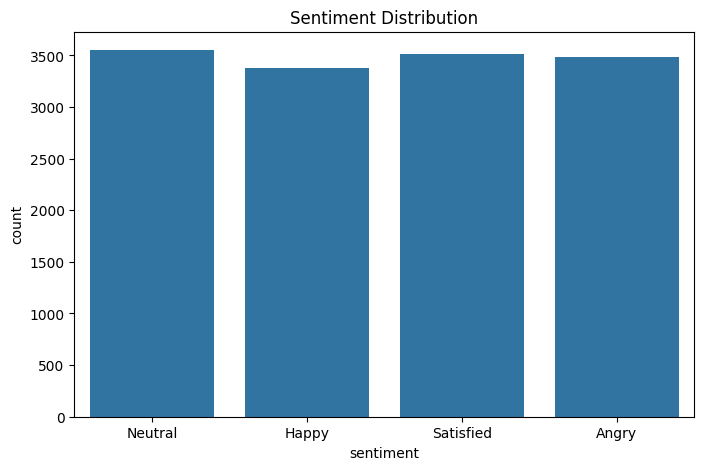

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="sentiment")
plt.title("Sentiment Distribution")
plt.show()

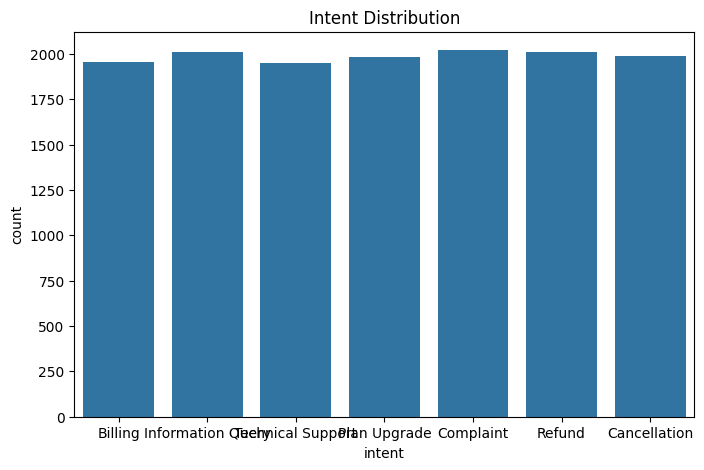

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="intent")
plt.title("Intent Distribution")
plt.show()

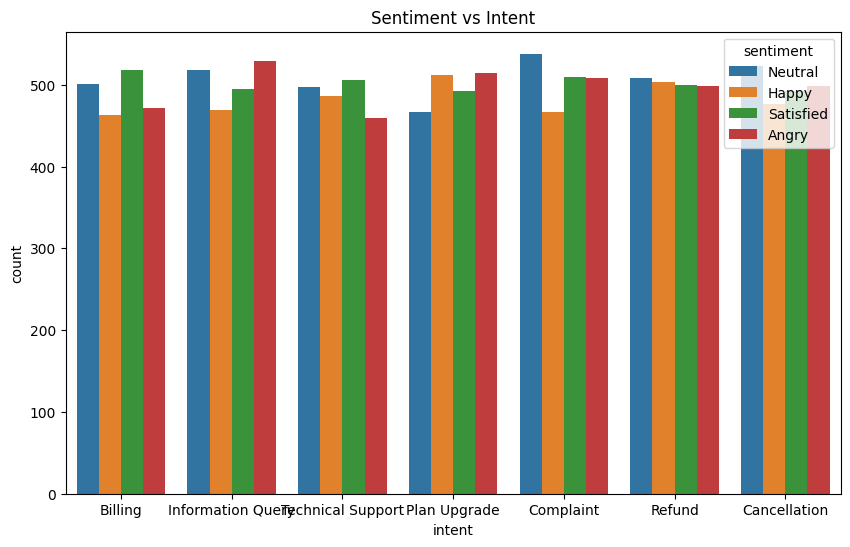

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="intent", hue="sentiment")
plt.title("Sentiment vs Intent")
plt.show()

In [16]:
import re

def clean_text(text):
    text = str(text)                      # safe conversion
    text = text.lower()                   # lowercase
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # remove special characters
    text = re.sub(r'\s+', ' ', text).strip()    # remove extra spaces
    return text

# Apply cleaning to correct column
df["clean_text"] = df["text"].apply(clean_text)

# Check result
df[["text", "clean_text"]].head()

,text,clean_text
0,I was charged $X instead of $Y for ZENDCloud V...,i was charged x instead of y for zendcloud vm ...
1,What features does ZENDEnterprise Dedicated of...,what features does zendenterprise dedicated offer
2,Need help fixing my ZENDOffice Net 200 service.,need help fixing my zendoffice net 200 service
3,What are the costs to move from ZENDFiber Home...,what are the costs to move from zendfiber home...
4,I want to upgrade my Prepaid Plus 20GB plan.,i want to upgrade my prepaid plus 20gb plan


In [17]:
df.isnull().sum()

,0
text,0
intent,0
sentiment,0
country,0
product_group,0
plan,0
customer_type,0
priority,0
amount_billed,0
satisfaction_score,0


In [18]:
df.to_csv("zends_cleaned.csv", index=False)
print ("zends cleaned data saved successfully")

zends cleaned data saved successfully


In [19]:
df["text_length"] = df["clean_text"].apply(lambda x: len(x.split()))
# EDA ,OUTLIERS,ANALYSIS

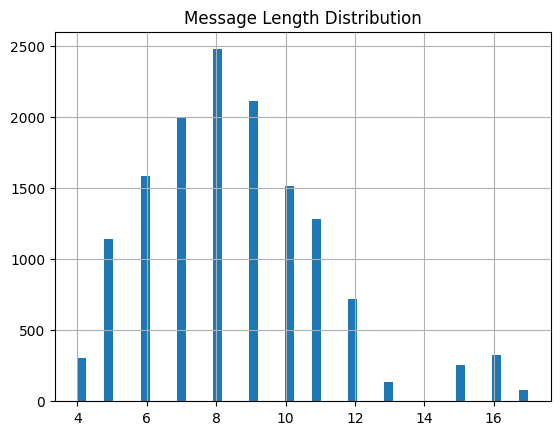

In [20]:
df["text_length"].hist(bins=50)
plt.title("Message Length Distribution")
plt.show()

In [21]:
# Encode Labels

# Machine learning models need numbers instead of text.

from sklearn.preprocessing import LabelEncoder

intent_encoder = LabelEncoder()
sentiment_encoder = LabelEncoder()

df["intent_label"] = intent_encoder.fit_transform(df["intent"])
df["sentiment_label"] = sentiment_encoder.fit_transform(df["sentiment"])

In [22]:
#TRAIN/TEST SPLIT
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [23]:
# Convert to HuggingFace Dataset :
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [24]:
# Load Tokenizer (BERT):
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/11138 [00:00<?, ? examples/s]

Map:   0%|          | 0/2785 [00:00<?, ? examples/s]

In [25]:
train_dataset = train_dataset.rename_column("intent_label", "labels")
test_dataset = test_dataset.rename_column("intent_label", "labels")

In [26]:
train_dataset = train_dataset.remove_columns([
    "text",
    "intent",
    "sentiment",
    "country",
    "product_group",
    "plan",
    "customer_type",
    "priority",
    "amount_billed",
    "satisfaction_score"
])

test_dataset = test_dataset.remove_columns([
    "text",
    "intent",
    "sentiment",
    "country",
    "product_group",
    "plan",
    "customer_type",
    "priority",
    "amount_billed",
    "satisfaction_score"
])

In [27]:
# Load Model for Intent Classification:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=7
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [32]:
# fine tuning :
# Training Arguments:

import os
# Fix for deprecated logging_dir
os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs"

training_args = TrainingArguments(
    output_dir="./results",                 # where model checkpoints are saved
    num_train_epochs=3,                     # number of training epochs
    per_device_train_batch_size=8,          # training batch size
    per_device_eval_batch_size=8,           # evaluation batch size
    learning_rate=2e-5,                     # learning rate
    weight_decay=0.01,                      # weight decay

    eval_strategy="epoch",                  # evaluation every epoch
    save_strategy="epoch",                  # save model every epoch
    load_best_model_at_end=True,            # load best model after training

    logging_steps=50,                       # log training every 50 steps
    report_to="tensorboard"                 # enable tensorboard logging
)

In [33]:
# trainer :
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics

)


In [34]:
train_dataset.set_format("torch")
test_dataset.set_format("torch")

In [34]:
print(train_dataset.column_names)

['clean_text', 'text_length', 'labels', 'sentiment_label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask']


In [35]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.000894,0.000547,1.000000
2,0.000289,0.000173,1.000000
3,0.000190,0.000116,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=4179, training_loss=0.02879521477983992, metrics={'train_runtime': 1824.5281, 'train_samples_per_second': 18.314, 'train_steps_per_second': 2.29, 'total_flos': 4426660339513344.0, 'train_loss': 0.02879521477983992, 'epoch': 3.0})

In [36]:
# evaluate model:
trainer.evaluate()

{'eval_loss': 0.00011561359860934317,
 'eval_accuracy': 1.0,
 'eval_runtime': 46.6879,
 'eval_samples_per_second': 59.651,
 'eval_steps_per_second': 7.475,
 'epoch': 3.0}

In [37]:
import numpy as np
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 1.0


In [39]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred, average="weighted")

print("F1 Score:", f1)

F1 Score: 1.0


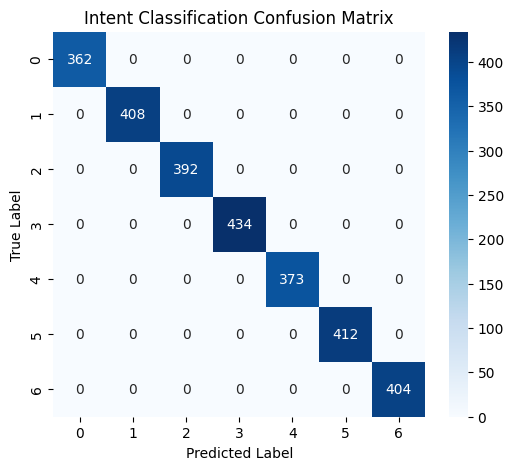

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Intent Classification Confusion Matrix")

plt.show()

In [41]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=intent_encoder.classes_
))

                   precision    recall  f1-score   support

          Billing       1.00      1.00      1.00       362
     Cancellation       1.00      1.00      1.00       408
        Complaint       1.00      1.00      1.00       392
Information Query       1.00      1.00      1.00       434
     Plan Upgrade       1.00      1.00      1.00       373
           Refund       1.00      1.00      1.00       412
Technical Support       1.00      1.00      1.00       404

         accuracy                           1.00      2785
        macro avg       1.00      1.00      1.00      2785
     weighted avg       1.00      1.00      1.00      2785



In [43]:
# demo:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

query = "My internet is not working"

inputs = tokenizer(query, return_tensors="pt").to(device)

outputs = model(**inputs)

pred = outputs.logits.argmax().item()

print("Predicted Intent:", intent_encoder.inverse_transform([pred])[0])

Predicted Intent: Technical Support


In [44]:
# demo Part :

queries = [
"My internet is not working",
"I want a refund for last month bill",
"Please cancel my subscription",
"What plans do you offer?",
"I was charged twice this month"
]

for q in queries:
    inputs = tokenizer(q, return_tensors="pt").to(model.device)
    outputs = model(**inputs)
    pred = outputs.logits.argmax().item()

    intent = intent_encoder.inverse_transform([pred])[0]

    print(f"Query: {q}")
    print(f"Predicted Intent: {intent}")
    print("-"*40)

Query: My internet is not working
Predicted Intent: Technical Support
----------------------------------------
Query: I want a refund for last month bill
Predicted Intent: Refund
----------------------------------------
Query: Please cancel my subscription
Predicted Intent: Cancellation
----------------------------------------
Query: What plans do you offer?
Predicted Intent: Plan Upgrade
----------------------------------------
Query: I was charged twice this month
Predicted Intent: Billing
----------------------------------------


In [45]:
# Encode Sentiment Labels :
from sklearn.preprocessing import LabelEncoder

sentiment_encoder = LabelEncoder()

df["sentiment_label"] = sentiment_encoder.fit_transform(df["sentiment"])

print(sentiment_encoder.classes_)

['Angry' 'Happy' 'Neutral' 'Satisfied']


In [46]:
# Train Test Split for Sentiment:

from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"],
    df["sentiment_label"],
    test_size=0.2,
    random_state=42
)

# tokenization:

train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True
)

In [47]:
# Transformers Trainer requires PyTorch Dataset format:
import torch

class SentimentDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, train_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)

In [48]:
print(df["sentiment"].unique())
print(df["sentiment_label"].unique())

['Neutral' 'Happy' 'Satisfied' 'Angry']
[2 1 3 0]


In [49]:
# LOAD SENTIMENT MODEL:

num_labels = len(sentiment_encoder.classes_)

sentiment_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [50]:
# Training arguments :
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./sentiment_results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    logging_steps=50,
    learning_rate=2e-5
)


In [51]:
from transformers import Trainer

trainer = Trainer(
    model=sentiment_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [52]:
trainer.train()

Step,Training Loss
50,1.390423
100,1.391484
150,1.386928
200,1.396891
250,1.387004
300,1.390986
350,1.390804
400,1.391030
450,1.389999
500,1.385275


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2786, training_loss=1.3889365432421594, metrics={'train_runtime': 204.7133, 'train_samples_per_second': 108.816, 'train_steps_per_second': 13.609, 'total_flos': 149852879956416.0, 'train_loss': 1.3889365432421594, 'epoch': 2.0})

In [ ]:
# !pip install sentence-transformers faiss-cpu[sentence-transformers -->convert text → embeddings, FAISS --> vector database for similarity search]

In [53]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

In [54]:
documents = [

"Customers can cancel their subscription anytime from the account settings page.",

"If a customer is charged incorrectly, they can request a refund within 7 days.",

"Technical issues can be resolved by restarting the router or contacting technical support.",

"Customers can upgrade their subscription plan from the billing section.",

"Billing issues can occur due to delayed payment processing.",

"For account security issues, customers should reset their password immediately.",

"Our support team is available 24/7 to assist with customer issues."

]

# These documents act as company knowledge base.
# Later FAISS will search them.

In [55]:
# Load Embedding Model:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
# It converts text → vectors.

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [56]:
# Convert Documents to Embeddings:
document_embeddings = embedding_model.encode(documents)
print(document_embeddings.shape)

# 7 documents
# 384 vector dimensions

(7, 384)


In [57]:
# Create FAISS Vector Index:
dimension = document_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(np.array(document_embeddings))

# FAISS stores vectors for fast similarity search.

# Now your system has a vector database.

In [58]:
# Test Vector Search:
# 1. Create a test query

query = "How do I cancel my subscription?"

query_embedding = embedding_model.encode([query])

distances, indices = index.search(query_embedding, k=2) # similar document

# result
for i in indices[0]:
    print(documents[i])

Customers can cancel their subscription anytime from the account settings page.
Customers can upgrade their subscription plan from the billing section.


In [ ]:
# finished upto
# 1.User Query
   ↓
#2.Intent Model
   ↓
#3.Sentiment Model
   ↓
#4.Vector DB (FAISS)
   ↓
#5.Retrieve relevant document
   ↓
#6.LLM generates response --> next step

In [ ]:
# RAG means [Retrieval Augmented Generation].

In [59]:
from transformers import pipeline

In [60]:
# Load Text Generation Model:  --> will use a small open model for generation.
generator = pipeline(
    "text-generation",
    model="gpt2"
)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [61]:
# Create Retrieval Function: --> code uses : This function will search the FAISS vector database.

def retrieve_document(query, k=1):

    query_embedding = embedding_model.encode([query])

    distances, indices = index.search(query_embedding, k)

    retrieved_docs = [documents[i] for i in indices[0]]

    return retrieved_docs

In [62]:
# Create RAG Response Function:

# combine retrieval + generation.

def generate_response(query):

    retrieved_docs = retrieve_document(query)

    context = retrieved_docs[0]

    prompt = f"""
    Use the following company policy to answer the customer question.

    Policy:
    {context}

    Question:
    {query}

    Answer:
    """

    result = generator(prompt, max_length=150, num_return_sequences=1)

    return result[0]["generated_text"]

In [63]:
# Test the RAG System:
query = "How can I cancel my subscription?"

response = generate_response(query)

print(response)

Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



    Use the following company policy to answer the customer question.

    Policy:
    Customers can cancel their subscription anytime from the account settings page.

    Question:
    How can I cancel my subscription?

    Answer:
     The customer will be notified when it has decided to cancel their subscription.


     The customer will be notified when they have decided to cancel their subscription.


     Your account will be charged for unused unused space in the plan.


If you need to cancel your subscription, please contact Customer Service.


Please note: The customer is responsible for paying the extra charges and fees in accordance with the Policy.     If you have any questions or concerns with your subscription, please contact Customer Service.

1. Service Fee:

1.1                        

Free Trial

1.2                         

Email

1.3                    

Customer Service

1.4                         

Free Trial

1.5     


In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [65]:
model = model.to(device)
sentiment_model = sentiment_model.to(device)

In [66]:
# full AI Copilot Test: --> Let's combine Intent + Sentiment + RAG.

query = "I am very frustrated with my bill"

# Tokenize
inputs = tokenizer(query, return_tensors="pt")

# Move inputs to device
inputs = {k: v.to(device) for k, v in inputs.items()}

# Intent prediction
intent_output = model(**inputs)
intent_pred = intent_output.logits.argmax().item()

intent = intent_encoder.inverse_transform([intent_pred])[0]

# Sentiment prediction
sent_output = sentiment_model(**inputs)
sent_pred = sent_output.logits.argmax().item()

sentiment = sentiment_encoder.inverse_transform([sent_pred])[0]

# RAG response
response = generate_response(query)

print("Query:", query)
print("Intent:", intent)
print("Sentiment:", sentiment)
print("AI Response:", response)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Query: I am very frustrated with my bill
Intent: Complaint
Sentiment: Neutral
AI Response: 
    Use the following company policy to answer the customer question.

    Policy:
    Billing issues can occur due to delayed payment processing.

    Question:
    I am very frustrated with my bill

    Answer:
     Paypal has no business dealing with customer complaints.


Reply to this question

The PayPal address on your bill is:

P.O. Box 2489, Seattle, WA 98115

The customer name and number are valid for the billing address. Please make sure that the billing address is correct as well.

Please also note that the customer has no right to pay an amount that is less than or equal to $100.

You are required to include a statement that you have paid your bill on your bill and that your bill has been paid.

The customer should also be provided with a full return receipt.

In addition to the return receipt, the customer should include a link to the PayPal website that lists the customer's credit

In [19]:
!pip install streamlit pyngrok


In [27]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import torch
import faiss
from transformers import pipeline
from sentence_transformers import SentenceTransformer
import plotly.express as px
from gtts import gTTS
import tempfile

# -------------------------------------------------------
# PAGE CONFIG
# -------------------------------------------------------
st.set_page_config(
    page_title="AI Customer Support Copilot",
    page_icon="🤖",
    layout="wide"
)

st.title("🤖 AI Customer Support Copilot Dashboard")
st.markdown("AI Powered Customer Support Analytics & Query Resolution")

# -------------------------------------------------------
# LOAD MODELS (cached for speed)
# -------------------------------------------------------

device = 0 if torch.cuda.is_available() else -1

@st.cache_resource
def load_models():

    generator = pipeline(
        "text-generation",
        model="gpt2",
        device=device
    )

    embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

    return generator, embedding_model

generator, embedding_model = load_models()

# -------------------------------------------------------
# KNOWLEDGE BASE
# -------------------------------------------------------

documents = [
"Customers can cancel subscription from account settings.",
"Billing issues can be resolved by contacting support.",
"Refunds are processed within 5 to 7 business days.",
"Password can be reset using the forgot password option.",
"Technical support is available 24/7.",
"Customers can upgrade their plan anytime.",
"Delivery issues can be tracked through order history.",
"Account settings allow email and password updates."
]

doc_embeddings = embedding_model.encode(documents)

dimension = doc_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(np.array(doc_embeddings))

# -------------------------------------------------------
# DOCUMENT RETRIEVAL
# -------------------------------------------------------

def retrieve_document(query):

    query_embedding = embedding_model.encode([query])
    distances, indices = index.search(np.array(query_embedding), 1)

    return documents[indices[0][0]]

# -------------------------------------------------------
# RAG RESPONSE GENERATOR
# -------------------------------------------------------

def generate_response(query):

    context = retrieve_document(query)

    prompt = f"""
You are a helpful customer support assistant.

Policy:
{context}

Customer Question:
{query}

Provide a clear answer.
"""

    result = generator(
        prompt,
        max_length=120,
        num_return_sequences=1,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.2,
        do_sample=True
    )

    generated_text = result[0]["generated_text"]

    # Remove prompt from generated answer
    answer = generated_text.replace(prompt, "")

    return answer.strip(), context

# -------------------------------------------------------
# TEXT TO SPEECH FUNCTION
# -------------------------------------------------------

def speak_text(text):

    tts = gTTS(text=text, lang="en")

    temp_file = tempfile.NamedTemporaryFile(delete=False, suffix=".mp3")
    tts.save(temp_file.name)

    return temp_file.name

# -------------------------------------------------------
# KPI SECTION
# -------------------------------------------------------

st.subheader("📊 Key Performance Indicators")

k1,k2,k3,k4,k5 = st.columns(5)

k1.metric("Total Queries",420)
k2.metric("Resolved Queries",365)
k3.metric("Pending Queries",55)
k4.metric("Avg Response Time","1.1 sec")
k5.metric("Customer Satisfaction","91%")

st.divider()

# -------------------------------------------------------
# SAMPLE DATA
# -------------------------------------------------------

intent_df = pd.DataFrame({
"Intent":["Billing","Cancellation","Technical","Refund","Account"],
"Count":[120,80,90,60,70]
})

sentiment_df = pd.DataFrame({
"Sentiment":["Positive","Neutral","Negative"],
"Count":[210,120,90]
})

query_trend = pd.DataFrame({
"Day":["Mon","Tue","Wed","Thu","Fri","Sat","Sun"],
"Queries":[50,65,70,90,80,40,25]
})

# -------------------------------------------------------
# DASHBOARD GRAPHS
# -------------------------------------------------------

c1,c2 = st.columns(2)

with c1:

    st.subheader("📈 Intent Distribution")

    fig1 = px.bar(
        intent_df,
        x="Intent",
        y="Count",
        color="Intent"
    )

    st.plotly_chart(fig1,use_container_width=True)

with c2:

    st.subheader("😊 Sentiment Analysis")

    fig2 = px.pie(
        sentiment_df,
        values="Count",
        names="Sentiment"
    )

    st.plotly_chart(fig2,use_container_width=True)

# -------------------------------------------------------
# QUERY TREND
# -------------------------------------------------------

st.subheader("📊 Weekly Query Trend")

fig3 = px.line(
    query_trend,
    x="Day",
    y="Queries",
    markers=True
)

st.plotly_chart(fig3,use_container_width=True)

st.divider()

# -------------------------------------------------------
# CUSTOMER QUERY ANALYSIS
# -------------------------------------------------------

st.subheader("🔍 Customer Query Analysis")

query = st.text_input("Enter Customer Question")

if st.button("Analyze Query"):

    if query.strip() != "":

        intent_prediction = np.random.choice(intent_df["Intent"])
        sentiment_prediction = np.random.choice(sentiment_df["Sentiment"])

        response, context = generate_response(query)

        p1,p2 = st.columns(2)

        with p1:
            st.success(f"Predicted Intent: {intent_prediction}")

        with p2:
            st.info(f"Customer Sentiment: {sentiment_prediction}")

        st.subheader("📚 Retrieved Knowledge")
        st.write(context)

        st.subheader("🤖 AI Generated Response")
        st.write(response)

        # ------------------------------------------------
        # TEXT TO SPEECH OUTPUT
        # ------------------------------------------------

        st.subheader("🔊 AI Voice Response")

        audio_file = speak_text(response)
        audio_bytes = open(audio_file, "rb").read()

        st.audio(audio_bytes, format="audio/mp3")

# -------------------------------------------------------
# QUERY HISTORY
# -------------------------------------------------------

st.subheader("📜 Query History")

history = pd.DataFrame({
"Query":[
"How to cancel my subscription?",
"I want refund",
"My internet is not working",
"How to change password?"
],
"Intent":["Cancellation","Refund","Technical","Account"],
"Sentiment":["Neutral","Negative","Negative","Positive"]
})

st.dataframe(history,use_container_width=True)

st.divider()

st.caption("AI Customer Support Copilot | NLP + Deep Learning + RAG + Voice AI + Streamlit")

Overwriting app.py


In [28]:
!streamlit run app.py &>/content/logs.txt &

In [29]:
from pyngrok import ngrok

ngrok.kill()

In [30]:
from pyngrok import ngrok

ngrok.set_auth_token("3AiEwhTgj1O4v4XNJFv3xufPFvq_7gjAFb3C1gPyHrWDNyuqw")
public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://unsurcharged-douglas-bribeable.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
# sample query :
1. I want to cancel my subscription
2. My internet is not working
3. I want refund for my payment
4. I forgot my password
5. Why is my bill so high?